# Single-cell analysis with scranpy

A full QC-to-UMAP workflow on the Zeisel mouse brain dataset

This workflow follows the Zeisel et al. (2015) mouse brain dataset
through quality control, normalization, feature selection, PCA,
graph-based clustering, and UMAP. The analysis uses
[`scranpy`](https://github.com/BiocPy/scranpy) with the full dataset
(20,006 genes and 3,005 cells), and ggnomics for visualization. For a
shorter introduction based on a subset of these cells, see [Getting
started](getting-started.ipynb).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("_includes").resolve()))
from setup import configure_warnings, ensure_matplotlib_initialized
ensure_matplotlib_initialized()
configure_warnings()

import numpy as np
import pandas as pd
import scranpy
import ggnomics as gg
from plotnine import theme_bw, theme, labs, facet_wrap, scale_color_gradient, element_text, coord_fixed

## 1. Fetching and inspecting the SCE

In [2]:
from data import load_zeisel_full

sce = load_zeisel_full()
sce.shape

(20006, 3005)

In [3]:
sce.get_assay_names()

['counts']

In [4]:
sce.get_column_data().get_column_names()

Names(['tissue', 'group #', 'total mRNA mol', 'well', 'sex', 'age', 'diameter', 'level1class', 'level2class'])

In [5]:
sce.get_alternative_experiment_names()

['repeat', 'ERCC']

The object contains two alternative experiments, `repeat` and `ERCC`
(spike-in) features. The analysis below uses the main 20,006-gene assay.

## 2. A mitochondrial-gene mask from verified row names

Mouse mitochondrial genes conventionally carry an `mt-` prefix. We
derive the QC subset directly from the row names:

In [6]:
row_names = sce.get_row_names()
mito_genes = [g for g in row_names if str(g).lower().startswith("mt-")]
len(mito_genes), mito_genes[:5]

(34, ['mt-Tl1', 'mt-Tn', 'mt-Tr', 'mt-Tq', 'mt-Ty'])

In [7]:
mito_mask = [str(g).lower().startswith("mt-") for g in row_names]

## 3. RNA QC metrics and cell filtering

`scranpy.compute_rna_qc_metrics` computes per-cell library size (`sum`),
number of detected genes (`detected`), and the mitochondrial proportion
for the `mito` subset we just defined; `suggest_rna_qc_thresholds`
derives outlier thresholds (median absolute deviation-based,
scran-style) and `filter_rna_qc_metrics` turns them into a boolean
keep-mask:

In [8]:
qc = scranpy.compute_rna_qc_metrics(sce.get_assay("counts"), subsets={"mito": mito_mask})
qc_df = qc.to_pandas()
qc_df.describe()

In [9]:
thresholds = scranpy.suggest_rna_qc_thresholds(qc)
keep = scranpy.filter_rna_qc_metrics(thresholds, qc)
f"{keep.sum()} / {len(keep)} cells retained"

'2874 / 3005 cells retained'

Plotting the QC metrics with `plot_coldata`, colored by whether a cell
passed filtering:

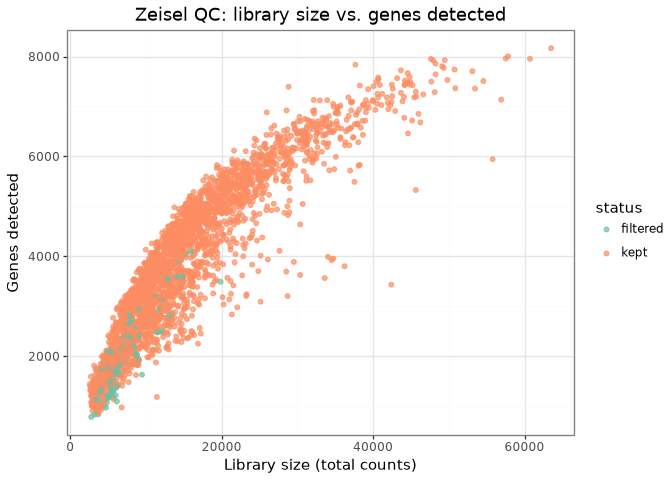

In [10]:
qc_plot_df = qc_df.copy()
qc_plot_df["status"] = np.where(keep, "kept", "filtered")

(
    gg.plot_coldata(qc_plot_df, x="sum", y="detected", color_by="status")
    + labs(x="Library size (total counts)", y="Genes detected", title="Zeisel QC: library size vs. genes detected")
    + theme_bw()
)

## 4. Filtering, normalization, and size factors

In [11]:
filtered = sce[:, keep]

cd = filtered.column_data
for col in ("sum", "detected", "subset_proportion.mito"):
    cd = cd.set_column(col, qc_df.loc[keep, col].to_numpy())
filtered = filtered.set_column_data(cd)

We pass the QC-derived library sizes explicitly as size factors,
following the `normalize_rna_counts_se` interface. This also avoids a
sparse-matrix shape issue in the installed scranpy version’s default
path:

In [12]:
size_factors = qc_df.loc[keep, "sum"].to_numpy()
normed = scranpy.normalize_rna_counts_se(filtered, assay_type="counts", size_factors=size_factors)
normed.get_assay_names()

['counts', 'logcounts']

## 5. Variance modelling and highly variable genes

In [13]:
hvg_out = scranpy.choose_rna_hvgs_se(normed, assay_type="logcounts", top=4000)
hvg_out.get_row_data().get_column_names()

Names(['featureType', 'mean', 'variance', 'fitted', 'residual', 'hvg'])

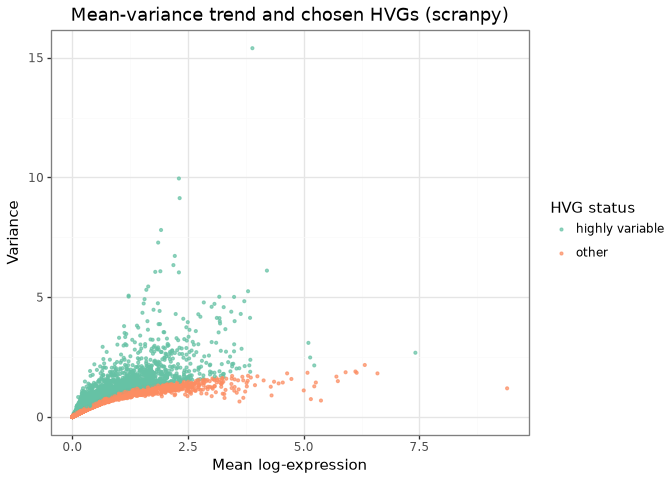

In [14]:
hvg_df = hvg_out.get_row_data().to_pandas()
# pandas treats a bool column as numeric, which would otherwise route this
# straight into plot_coldata's continuous-color branch - map to a category
# label explicitly so it's treated (and legended) as discrete.
hvg_df["HVG status"] = hvg_df["hvg"].map({True: "highly variable", False: "other"})
(
    gg.plot_coldata(hvg_df, x="mean", y="variance", color_by="HVG status")
    + labs(title="Mean-variance trend and chosen HVGs (scranpy)", x="Mean log-expression", y="Variance")
    + theme_bw()
)

## 6. PCA

In [15]:
hvg_flags = hvg_out.get_row_data().get_column("hvg")
pca_out = scranpy.run_pca_se(hvg_out, features=hvg_flags, number=25, assay_type="logcounts")
pca_out.get_reduced_dim_names()

['PCA']

## 7. Nearest-neighbor graph, clustering, and UMAP

`run_all_neighbor_steps_se` builds the shared-nearest-neighbor graph,
runs graph-based (Leiden/Louvain-style multilevel) clustering, and
computes both UMAP and t-SNE embeddings in one call:

In [16]:
final = scranpy.run_all_neighbor_steps_se(pca_out, reddim_type="PCA")
final.get_reduced_dim_names()

['PCA', 'TSNE', 'UMAP']

In [17]:
final.get_column_data().get_column_names()

Names(['tissue', 'group #', 'total mRNA mol', 'well', 'sex', 'age', 'diameter', 'level1class', 'level2class', 'sum', 'detected', 'subset_proportion.mito', 'size_factor', 'clusters'])

In [18]:
n_clusters = len(set(final.column_data.get_column("clusters")))
f"{n_clusters} graph-based clusters"

'14 graph-based clusters'

`run_scranpy_pipeline_on_zeisel()` caches the processed SCE for later
examples:

In [19]:
from data import run_scranpy_pipeline_on_zeisel

final = run_scranpy_pipeline_on_zeisel()

## 8. Plotting PCA and UMAP

The same `plot_pca` and `plot_umap` functions can colour cells by
cluster, the supplied cell-class annotation, a QC metric, or expression
of a selected gene. The SCE adapter retrieves coordinates, annotations,
and assays from their corresponding slots.

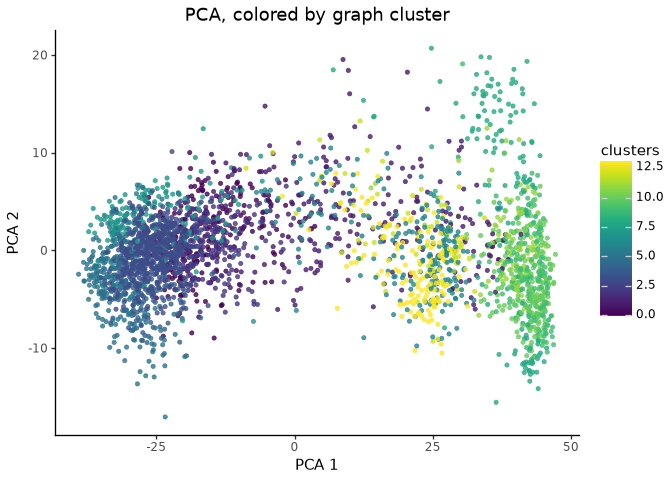

In [20]:
gg.plot_pca(final, color="clusters") + labs(title="PCA, colored by graph cluster")

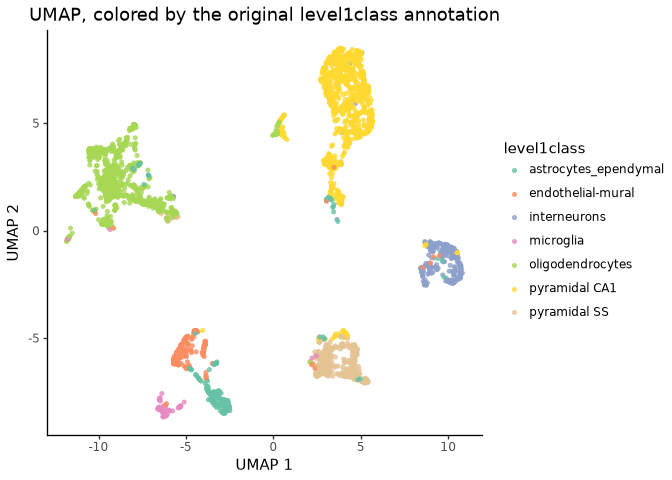

In [21]:
gg.plot_umap(final, color="level1class") + labs(title="UMAP, colored by the original level1class annotation")

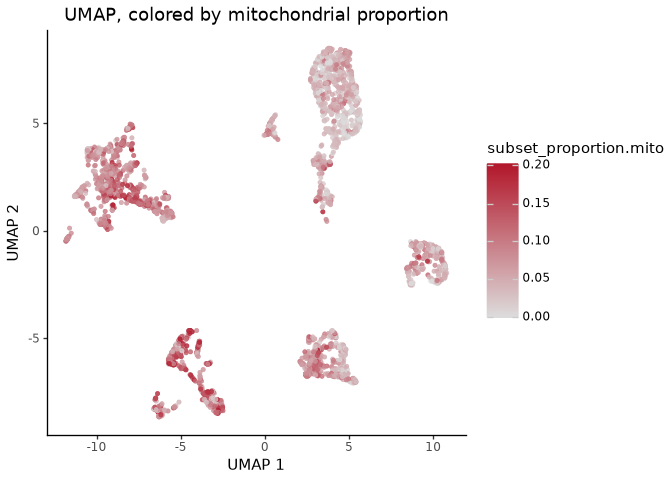

In [22]:
gg.plot_umap(final, color="subset_proportion.mito") + scale_color_gradient(low="#dddddd", high="#B2182B") + labs(title="UMAP, colored by mitochondrial proportion")

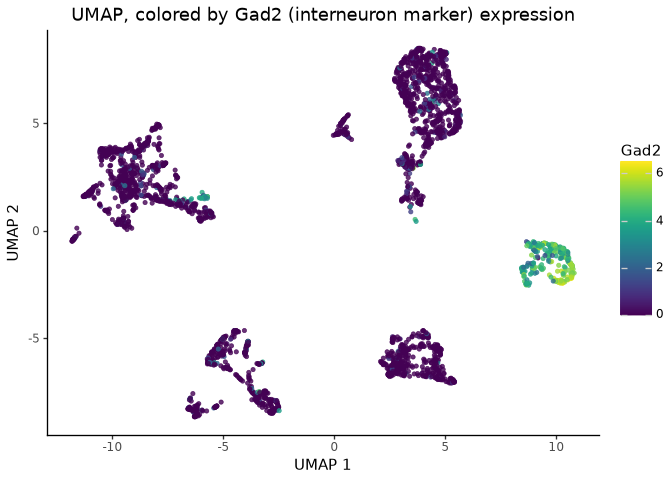

In [23]:
gg.plot_umap(final, color="Gad2", layer="logcounts") + labs(title="UMAP, colored by Gad2 (interneuron marker) expression")

### Point-order control

`order=` draws selected categories last, which keeps small populations
visible in dense embeddings:

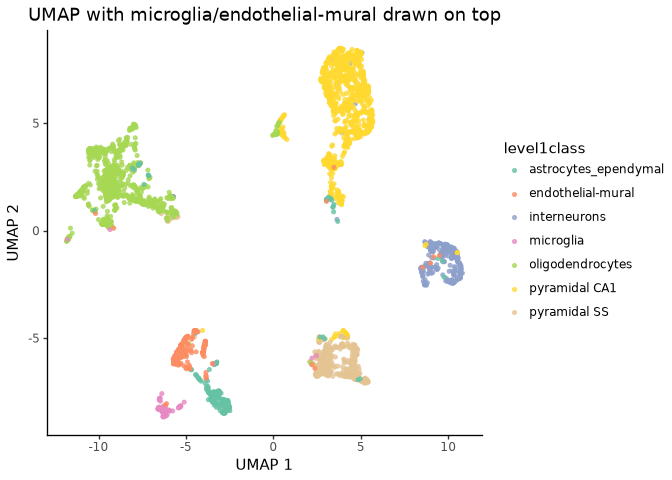

In [24]:
gg.plot_umap(final, color="level1class", order=["microglia", "endothelial-mural"]) + labs(title="UMAP with microglia/endothelial-mural drawn on top")

### Faceting

Use `facet_by=` when splitting an embedding by a metadata field. The
plotting frame built by `plot_umap` contains only the coordinates and
requested annotations, so a post-hoc `facet_wrap()` cannot refer to
other SCE columns.

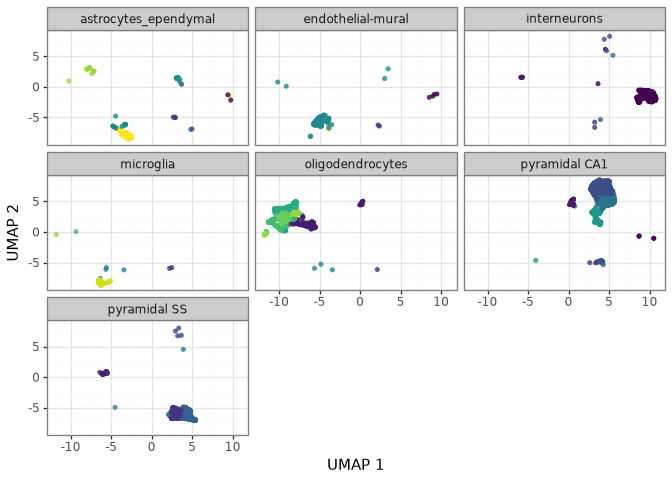

In [25]:
gg.plot_umap(final, color="clusters", facet_by="level1class") + theme_bw() + theme(legend_position="none")

## 9. Descriptive comparison to the original annotation

The graph-based clusters were calculated without using Zeisel’s curated
`level1class` or `level2class` labels. A cross-tabulation provides a
useful descriptive comparison, although it is not a formal measure of
clustering accuracy:

In [26]:
cd = final.column_data.to_pandas()
comparison = pd.crosstab(cd["clusters"], cd["level1class"])
comparison

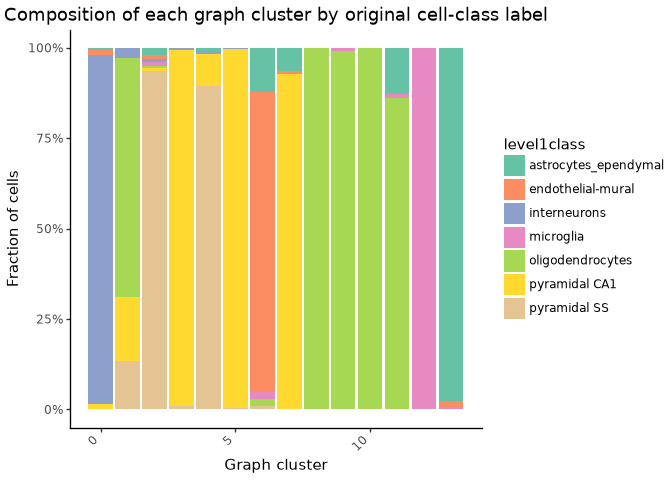

In [27]:
gg.plot_abundance(cd, group_by="clusters", color_by="level1class") + labs(
    title="Composition of each graph cluster by original cell-class label",
    x="Graph cluster", y="Fraction of cells",
)

Several clusters are dominated by a single broad class, including
oligodendrocyte- and astrocyte-rich clusters. Larger classes such as
pyramidal neurons are distributed across several clusters, reflecting
variation below the broad `level1class` annotation.

## 10. Expression violins and dot plots

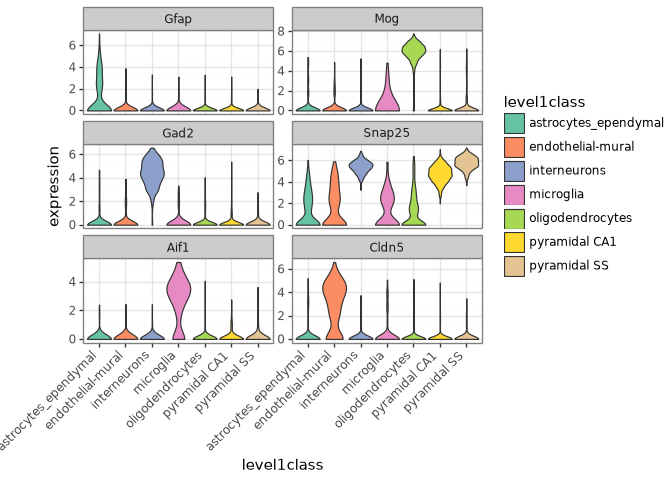

In [28]:
markers = ["Gfap", "Mog", "Gad2", "Snap25", "Aif1", "Cldn5"]
gg.plot_expression(final, features=markers, group_by="level1class", layer="logcounts", log1p=False, ncol=2) + theme_bw() + theme(axis_text_x=element_text(rotation=45, hjust=1))

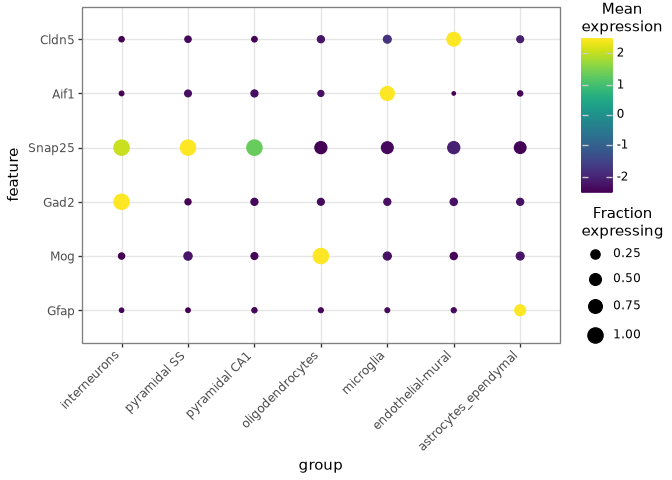

In [29]:
gg.plot_dot(final, features=markers, group_by="level1class", layer="logcounts") + theme_bw() + theme(axis_text_x=element_text(rotation=45, hjust=1))

## 11. Heatmap

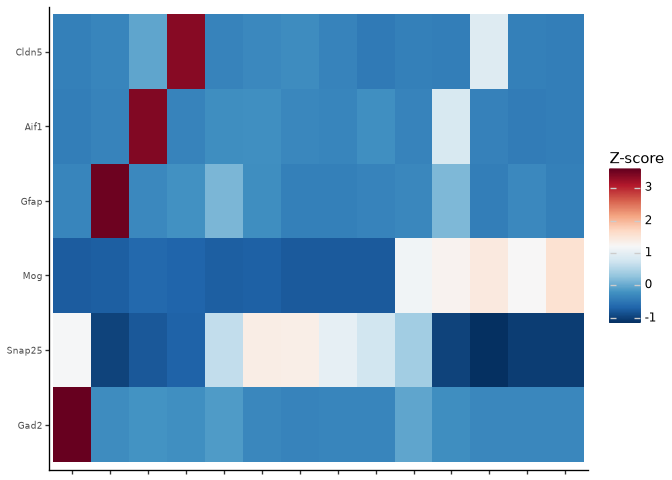

In [30]:
gg.plot_heatmap(final, features=markers, group_by="clusters", layer="logcounts", cluster_rows=True, cluster_cols=True)

## 12. Converting to AnnData and reproducing the UMAP

In the installed versions, PCA metadata are stored as a
`biocutils.NamedList`, whereas `.to_anndata()` expects a mutable mapping
for AnnData’s `.uns`. The UMAP plot does not require those PCA metadata,
so we omit them during conversion:

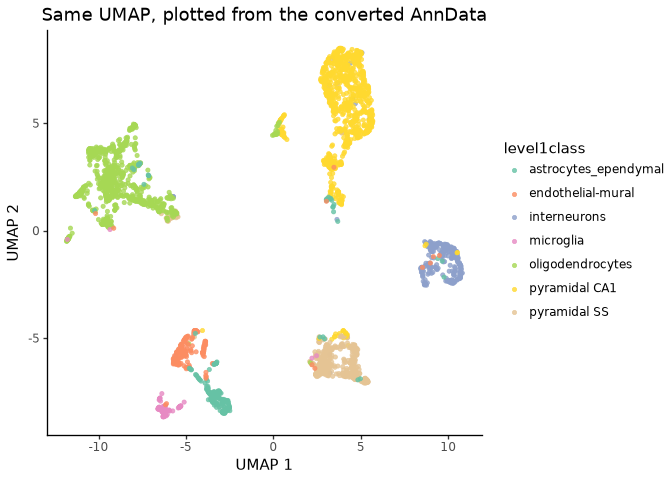

In [31]:
final_for_export = final.set_metadata({})
adata, _alt = final_for_export.to_anndata()
adata.X = adata.layers["logcounts"]
gg.plot_umap(adata, color="level1class") + labs(title="Same UMAP, plotted from the converted AnnData")

## 13. A custom plotnine extension

The returned UMAP can be extended with ordinary plotnine components.
Here we fix the aspect ratio and add a caption from values calculated
above:

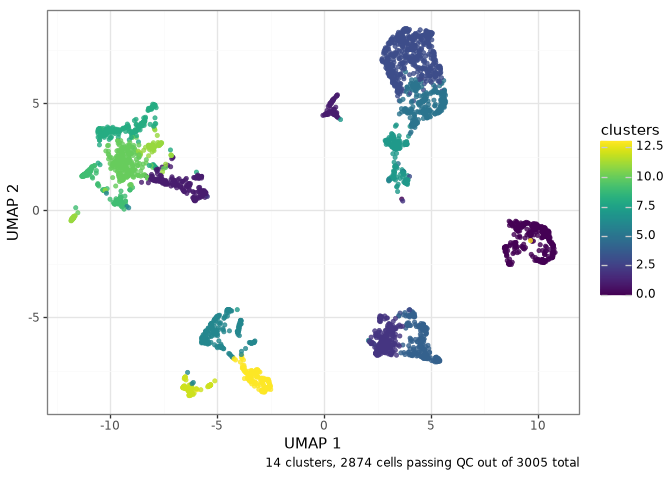

In [32]:
gg.plot_umap(final, color="clusters") + coord_fixed() + labs(
    caption=f"{n_clusters} clusters, {final.shape[1]} cells passing QC out of {sce.shape[1]} total"
) + theme_bw()

## Next

- [Bulk RNA-seq](bulk-rnaseq.ipynb) for PyDESeq2-based differential
  expression.
- [Multimodal](multimodal.ipynb) for RNA/ADT CITE-seq data.
- [Specialized plots](specialized-plots.ipynb) uses the processed Zeisel
  object for statistics, significance brackets, and palette examples.